# Анализ медицинских данных

## Задание 1. Подготовка окружения и знакомство с данными

In [ ]:
import pandas as pd

In [40]:
df = pd.read_csv('clinical_trial_data.csv')
df.head()

,PatientID,Group,Score
0,1,Placebo,60.870471
1,2,Drug,63.997831
2,3,Placebo,60.917608
3,4,Placebo,40.124311
4,5,Placebo,57.803281


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PatientID  200 non-null    int64  
 1   Group      200 non-null    object 
 2   Score      200 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.8+ KB


In [32]:
df.describe()

,PatientID,Score
count,200.000000,200.000000
mean,100.500000,65.267600
std,57.879185,11.088616
min,1.000000,39.748574
25%,50.750000,58.021821
50%,100.500000,65.135267
75%,150.250000,72.504527
max,200.000000,98.527315


## Задание 2 

Нам предстоит работать с табличными данными, которые включают в себя поля:
1. PatientID - идентификатор пациента, все пациенты обезличены. ФЗ 323 (INT64). Всего 200 пациентов. 
2. Group - препарат, который использовался при лечении или плацебо (OBJECT). Нету четкой дифференцировки препарата используют общий термин - drug. Какого-то хера плацебо слишком эффективное, нам бы за такое на кафедре ууух.... 
3. Score - результат действия препарата  (FLOAT64) 

In [48]:
drug_group = df[df["Group"] == "Drug"]["Score"]
placebo_group = df[df["Group"] == "Placebo"]["Score"]

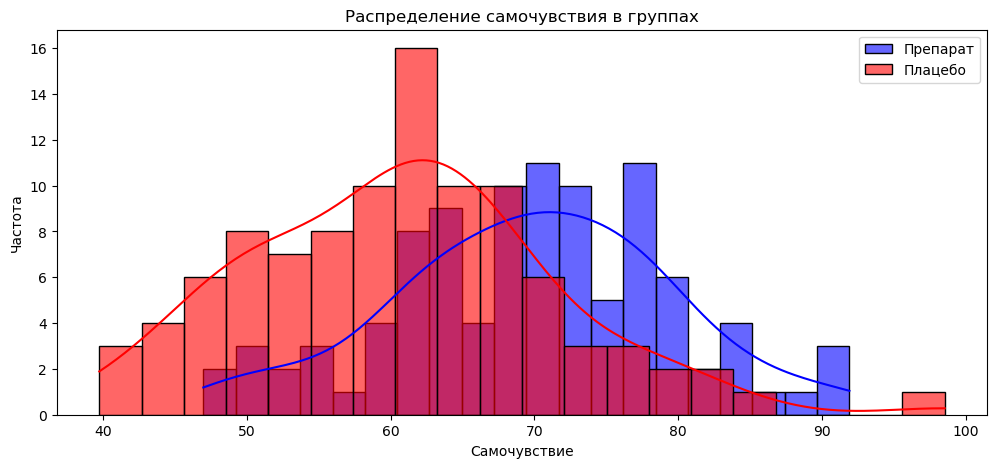

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

sns.histplot(drug_group, kde=True, color="blue", label="Препарат", bins=20, alpha=0.6)
sns.histplot(placebo_group, kde=True, color="red", label="Плацебо", bins=20, alpha=0.6)

plt.legend()
plt.title("Распределение самочувствия в группах")
plt.xlabel("Самочувствие")
plt.ylabel("Частота")
plt.show()

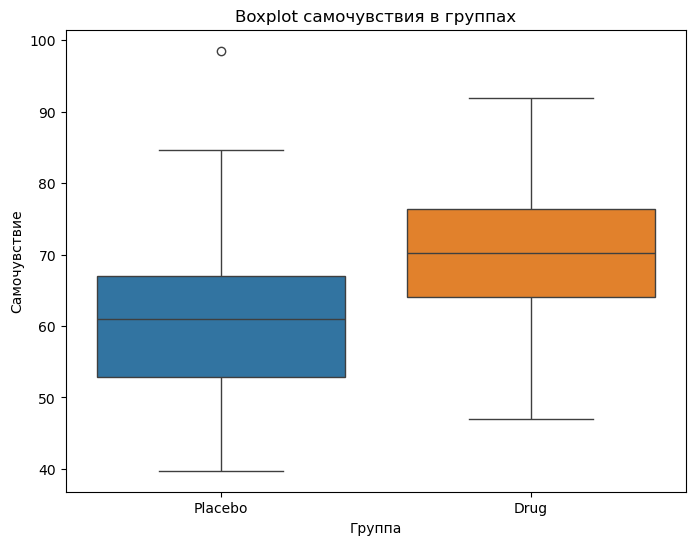

In [102]:
plt.figure(figsize=(8,6))

sns.boxplot(data = df,x = df["Group"], y = df["Score"], hue = "Group")

plt.legend()
plt.title("Boxplot самочувствия в группах")
plt.xlabel("Группа")
plt.ylabel("Самочувствие")
plt.show()

1. В гистограмме отчетливо видно, что эффективность действия drug значительно выше, чем Placebo. Рассматривая более значимую статистическую выборкую, которая не вкючает в себя единичные случаии, для такого детального анализа рассмотрим boxplot.
2. В boxplot указывает на меньшую разбросаность данных у drug в "ящике", что может говорить о более сабильном результате.
3. Далее статистика и котики

## Задание 3 

тест Шапиро — Уилка - один из критериев библиотеки скипи(не скайпай, киберпанкеры поймут), который мы будем использовать для проверки того или иного атрибута на нормальное распределение. 

Нормальное распределение в статистике — это особый тип распределения, при котором большинство значений сосредоточено около среднего. Его также называют гауссовым распределением, законом Гаусса или колоколообразным распределением, а его график — кривой Гаусса, или гауссианой. 

Суть закона нормального распределения: значения случайной величины сгруппированы вокруг среднего значения, и чем дальше от среднего значения, тем меньше вероятность того, что такое значение появится

В основе проверки на нормальность лежит проверка гипотез. Нулевая гипотеза  - данные распределены нормально . Альтернативная гипотеза - данные не имеют нормаьного распределения 

Проведем первый критерий Шапиро - Уилка , возварщающий значение вычислительно статистикики и p-значение. В качестве критического значения в большинстве случе берется 0.05. При p-значении меньше 0.05 мы вынуждены отклонить нулевую гипотезу.   


In [143]:
import numpy as nm
import scipy
from scipy import stats 

stat, drug_p = scipy.stats.shapiro(drug_group)

print('Statistics=%.3f, p-value=%.3f' % (stat, drug_p))

alpha = 0.05
if drug_p > alpha:
    print('Принять гипотезу о нормальности для drug')
else:
    print('Отклонить гипотезу о нормальности для drug')


stat, placebo_p = scipy.stats.shapiro(placebo_group)

print('Statistics=%.3f, p-value=%.3f' % (stat, placebo_p))

alpha = 0.05
if placebo_p > alpha:
    print('Принять гипотезу о нормальности для placebo')
else:
    print('Отклонить гипотезу о нормальности для placebo')


Statistics=0.989, p-value=0.618
Принять гипотезу о нормальности для drug
Statistics=0.981, p-value=0.152
Принять гипотезу о нормальности для placebo


На основании того, что p-value > 0.05 (критического значения или a-value), мы делаем вывод о нормальности распределения 

____________________________________________________________________________________________________________________

Тест Левена проверяет равенство дисперсий между группами. Дисперсия — это мера разброса данных: если дисперсии сильно отличаются, это может повлиять на корректность статистических тестов.

1. Почему важно проверять гомогенность дисперсий?
Когда мы сравниваем две группы (например, принимающих препарат и плацебо), мы часто используем t-тест. Однако t-тест предполагает, что обе группы имеют примерно одинаковые дисперсии.

Если дисперсии разные (гетерогенные дисперсии), то стандартный t-тест может дать неверные результаты, и в этом случае нужно использовать его модифицированную версию или непараметрический тест.

📌 Пример:

Представь, что в группе препарата самочувствие очень стабильно (почти все оценки 7–8).
А в группе плацебо самочувствие сильно разбросано (от 3 до 10).
Тогда обычный t-тест может дать искажённые результаты, так как предполагает одинаковый разброс в обеих группах.
Поэтому перед использованием t-теста проверяют гомогенность дисперсий, например, с помощью теста Левена.

Тест Левена проверяет гипотезу:

H₀ (нулевая гипотеза): дисперсии равны (группы имеют одинаковый разброс данных).
H₁ (альтернативная гипотеза): дисперсии разные (группы имеют разный разброс данных).
Если p-value < 0.05, это означает, что дисперсии не равны и нужно использовать корректирующий статистический тест.


In [186]:
stat, p_value = scipy.stats.levene(drug_group, placebo_group)

print('Statistics=%.3f, p-value=%.3f' % (stat, p_value))

alpha = 0.05
if p_value > alpha:
    print('Принять гипотезу о *равности* дисперсий между drug и placebo ')
else:
    print('Принять гипотезу о *разности* дисперсий между drug и placebo ')

Statistics=0.380, p-value=0.538
Принять гипотезу о *равности* дисперсий между drug и placebo 


1.На основании того, что p-value > 0.05 (критического значения или a-value), мы делаем вывод о *равности* дисперсий между drug и placebo и принимаем H0
2.Дисперсии равны → можно использовать обычный t-тест

________________________________________________________________________________________________________________________________________________________


T-тест Стьюдента: зачем он нужен и когда применять?
T-тест Стьюдента используется для сравнения средних значений двух групп и проверки, есть ли между ними статистически значимые различия.

1. Когда использовать t-тест?
Если у нас есть две независимые группы (например, группа, принимающая препарат, и группа, принимающая плацебо), t-тест помогает ответить на вопрос:

🔹 Являются ли различия в средних значениях между группами случайными, или они значимы?

📌 Примеры применения t-теста:
✅ Клинические исследования: улучшает ли препарат самочувствие пациентов по сравнению с плацебо?
✅ Маркетинговые исследования: отличаются ли продажи до и после рекламной кампании?
✅ Образование: есть ли разница в оценках учеников из двух разных школ?

2. Гипотезы t-теста
При проведении t-теста мы проверяем две гипотезы:

H₀ (нулевая гипотеза): средние значения в двух группах равны (различия случайны).
H₁ (альтернативная гипотеза): средние значения различаются.
Если p-value < 0.05, то мы отвергаем нулевую гипотезу и говорим, что различия значимы.

3. Условия для применения t-теста
Чтобы t-тест работал корректно, должны выполняться две ключевые предпосылки:

Нормальное распределение данных (проверяется тестом Шапиро-Уилка).
Равенство дисперсий (проверяется тестом Левена).
Если условия не выполняются, используем:

Welch’s t-test (если дисперсии не равны).
Тест Манна-Уитни (если данные не нормальны).


In [201]:
stat, p_value = scipy.stats.ttest_ind(drug_group, placebo_group)

print('Statistics=%.3f, p-value=%.3f' % (stat, p_value))

alpha = 0.05
if p_value > alpha:
    print('Принять гипотезу о *равности* средних значений(различия случайны)  между drug и placebo')
else:
    print('Принять гипотезу о *разности* средних значений(различия значимы)  между drug и placebo')

Statistics=6.403, p-value=0.000
Принять гипотезу о *разности* средних значений(различия значимы)  между drug и placebo


Интерпретация результата
Если p-value ≥ 0.05 → различий нет, препарат не оказывает значимого влияния.
Если p-value < 0.05 → различия значимы, препарат действительно влияет на самочувствие.

 p-value=0.000 значит различия значимы и препарат действительно влияет на самочувствие

________________________________________________________________________________________________________________________________________________________


Оценка размера эффекта: коэффициент d Коэна
1. Что такое коэффициент d Коэна и зачем он нужен?
Статистические тесты (например, t-тест) говорят нам, есть ли статистически значимая разница между группами, но не говорят, насколько эта разница велика.

▶ Коэффициент d Коэна (Cohen’s d) измеряет размер эффекта – то есть, насколько сильно одно условие (например, приём препарата) влияет на результат (самочувствие).

2. Почему t-теста недостаточно?
✅ t-тест говорит только о том, есть ли разница между группами, но не оценивает её величину.
✅ p-value зависит от размера выборки: при больших данных даже маленькие различия могут быть значимыми, а при маленьких — даже сильные различия могут быть незначимыми.
✅ Коэффициент d Коэна показывает насколько большая разница между группами, независимо от размера выборки.

In [208]:
import numpy as np
# Средние значения
mean_drug = np.mean(drug_group)
mean_placebo = np.mean(placebo_group)

# Стандартные отклонения
std_drug = np.std(drug_group, ddof=1)  # ddof=1 делает выборочное отклонение
std_placebo = np.std(placebo_group, ddof=1)

# Объединённое стандартное отклонение (SD_pooled)
sd_pooled = np.sqrt((std_drug**2 + std_placebo**2) / 2)

# Рассчитываем d Коэна
cohens_d = (mean_drug - mean_placebo) / sd_pooled

print(f"Коэффициент d Коэна: {cohens_d}")

Коэффициент d Коэна: 0.9055472649662838


 Интерпретация результата
Если d = 0.2, эффект маленький → препарат даёт небольшое улучшение.
Если d = 0.5, эффект средний → препарат заметно улучшает самочувствие.
Если d = 0.8+, эффект большой → препарат значительно лучше плацебо.

на основании полученого результата делаем вывод, что эффект большой → препарат значительно лучше плацебо.